In [1]:
import sys
import os
import pytest

from tqdm.notebook import tqdm, trange
import jax
import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax import Array
from jax.flatten_util import ravel_pytree
import equinox as eqx
from zodiax.diffops import hessian
from zodiax.optimisation import eigen_projection

from optax import sgd, adam
import optimistix as optx

import amigo as amg
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller
from dorito.stats import disco_regularised_loss_fn


from kneed import KneeLocator
from sklearn.decomposition import PCA

import dLux.utils as dlu

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.jax_gaussian import gaussian_filter


In [2]:
master_key = jr.key(0)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"]

disco_HD100546_path = os.path.join(
    main_data_path, "jwst", "HD100546", "disco", "cal_vis_HD-100546.npy"
)
disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)

In [3]:
model_key, master_key = jr.split(master_key, 2)
model_type = "PPD"
i = 16
model_names = [
    "0_0",
    "0_2",
    "1_0",
    "1_2",
    "2_0",
    "2_1",
    "2_2",
    "3_0",
    "3_1",
    "3_2",
    "4_0",
    "4_1",
    "4_2",
    "7_0",
    "7_1",
    "7_2",
    "7_4",
    "7_5",
    "8_0",
    "8_2",
    "8_3",
    "8_4",
    "8_5",
    "8_6",
]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"model_{model_name}.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


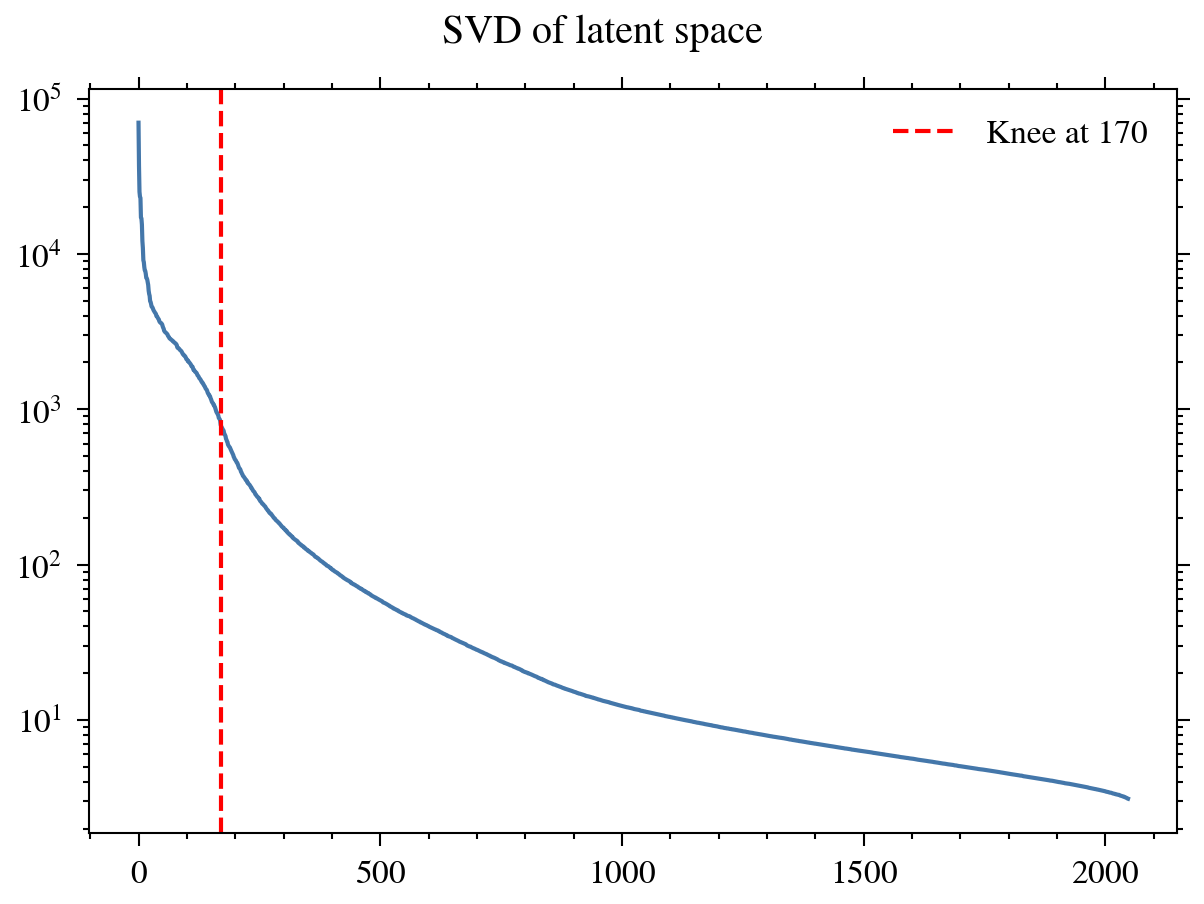

SVD Path: _data/autoencoder/svd/PPD_model_7_4_svd.npz
Knee at 170


In [4]:
svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of latent space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd_path}")
print(f"Knee at {k1.knee}")

In [5]:
tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out = int(k1.knee)
new_encode_latent_weights = (
    base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
)
new_encode_latent_biases = (
    base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
)
new_encode_linear = eqx.nn.Linear(
    in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.weight, new_encode_linear, new_encode_latent_weights
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers[-1],
    base_autoencoder,
    trained_new_encode_linear,
)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[
        :knee
    ]


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in = int(k1.knee)
new_decode_latent_weights = (
    sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
)
new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear = eqx.nn.Linear(
    in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.weight, new_decode_linear, new_decode_latent_weights
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers[2],
    sutured_ae_struct,
    trained_new_decode_linear,
)

sutured_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
)
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f"Suture Model Path: {sutured_model_path}")

def sum2unity(X):
    pix_sum = np.sum(X, axis=(1,2), keepdims=True)
    norm_pix = X/pix_sum
    return norm_pix

sum2unity_layer     = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae     = eqx.tree_at(
        lambda m: m.modules[1].layers,
        sutured_ae,
        sutured_ae.modules[1].layers + [sum2unity_layer]
)

# encoder, decoder = sutured_ae.modules
encoder, decoder = norm_sutured_ae.modules

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


In [6]:
data = ppd_51x51_data['x_train']
batch_size = 250

In [7]:
def encode_batch(batch):
    return jax.vmap(encoder)(batch)

latents = []
for i in range(0, len(data), batch_size):
    batch = data[i:i + batch_size]
    batch = batch.reshape(-1, 1, batch.shape[-1], batch.shape[-2])
    latents.append(encode_batch(batch))
train_latents = np.concatenate(latents)


In [8]:
train_latents_mean = np.mean(train_latents, axis=0)
train_latents_centered = train_latents - train_latents_mean
u, s, v = np.linalg.svd(train_latents_centered, full_matrices=False)

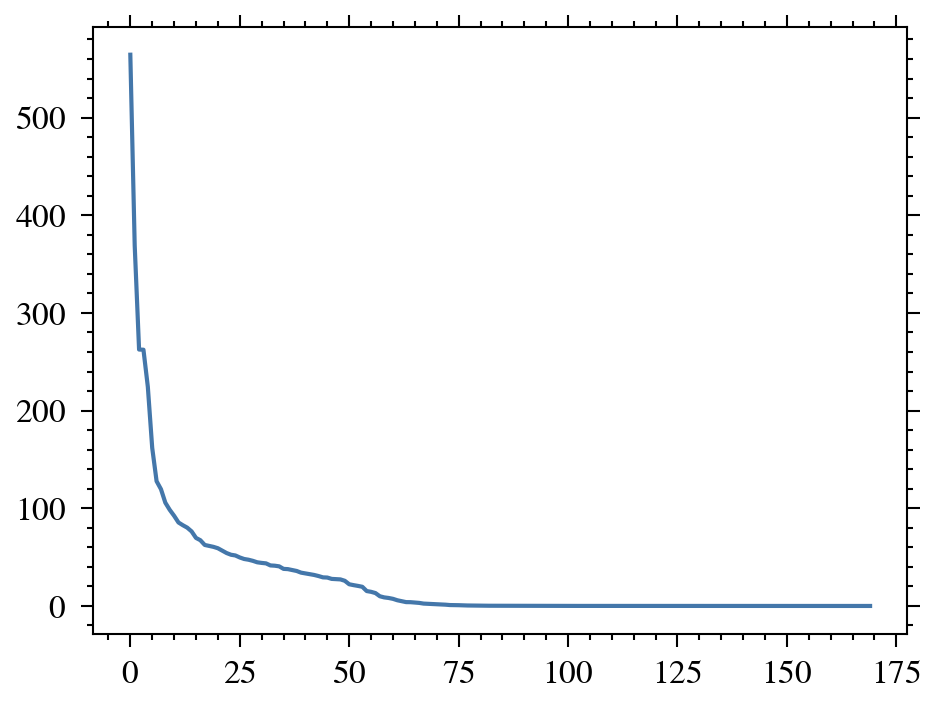

In [9]:
plt.plot(np.arange(len(s)), s)

In [10]:
pca = PCA(n_components=2)

In [11]:
pca_comps = pca.fit_transform(train_latents)

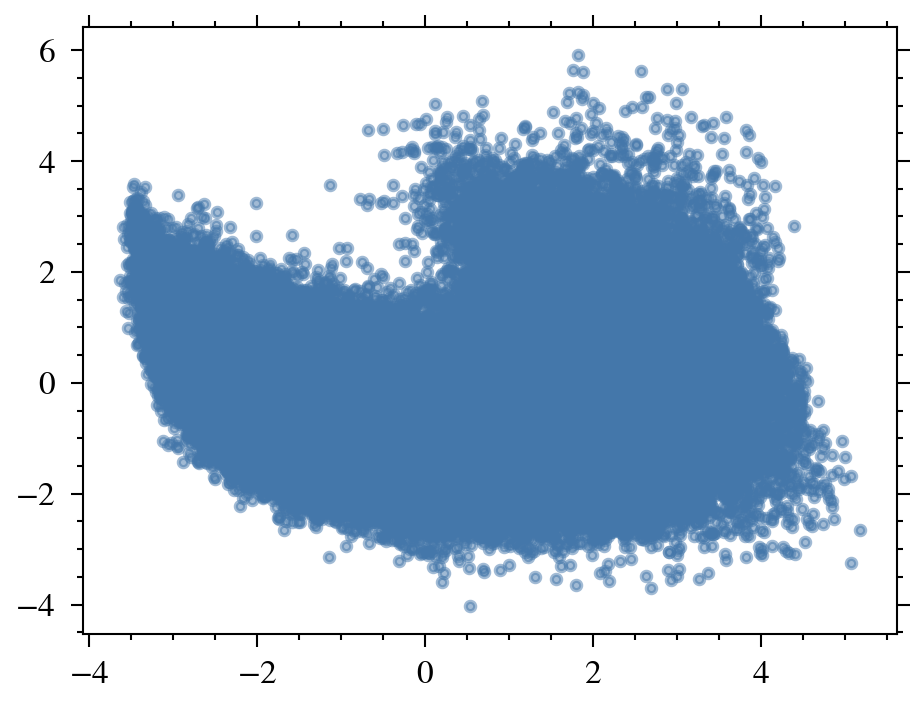

In [12]:
plt.scatter(pca_comps[:,0], pca_comps[:,1], s=5,alpha=0.5)

In [13]:
np.std(pca_comps[:,0])

Array(1.7848576, dtype=float32)

In [14]:
np.std(pca_comps[:,1])

Array(1.1674619, dtype=float32)

In [15]:
v

Array([[-2.24432591e-02,  7.21812248e-03, -1.48952007e-02, ...,
        -4.51862544e-01, -8.07266682e-02, -1.34932101e-01],
       [-5.02324291e-03, -2.52526179e-02,  1.08524561e-02, ...,
        -1.23337135e-01,  5.61686195e-02,  2.50986278e-01],
       [-3.94201255e-04, -1.04475869e-02, -5.61863109e-02, ...,
        -7.27351680e-02, -4.46433108e-03,  3.35737437e-01],
       ...,
       [ 0.00000000e+00, -3.78314227e-01, -8.13620985e-02, ...,
        -6.54312223e-03,  1.49040818e-02, -7.92871788e-03],
       [ 0.00000000e+00, -2.76459694e-01, -2.67097563e-01, ...,
         9.80897248e-03, -6.31704926e-03,  9.87309869e-03],
       [ 0.00000000e+00,  9.18512195e-02,  1.72067806e-01, ...,
        -3.56598198e-03, -3.74451280e-03, -8.86890292e-03]],      dtype=float32)

In [16]:
def embed2(X, m, s, v):
    return (X - m) @ v.T / np.sqrt(s ** 2 / 170)


embed_layer = eqx.nn.Lambda(
    lambda z: embed2(z, train_latents_mean, s=s, v=v)
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[0].layers,
    norm_sutured_ae,
    norm_sutured_ae.modules[0].layers + [embed_layer],
)


def unembed2(embedded, m, s, v):
    return ((embedded) * np.sqrt(s ** 2 / 170)) @ v + m


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed2(z, train_latents_mean, s, v)
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    norm2_sutured_ae,
    [unembed_layer] + norm2_sutured_ae.modules[1].layers,
)
encoder, decoder = norm2_sutured_ae.modules

In [17]:
def encode_batch(batch):
    return jax.vmap(encoder)(batch)

latents2 = []
for i in range(0, len(data), batch_size):
    batch = data[i:i + batch_size]
    batch = batch.reshape(-1, 1, batch.shape[-1], batch.shape[-2])
    latents2.append(encode_batch(batch))
train_latents2 = np.concatenate(latents2)


KeyboardInterrupt: 

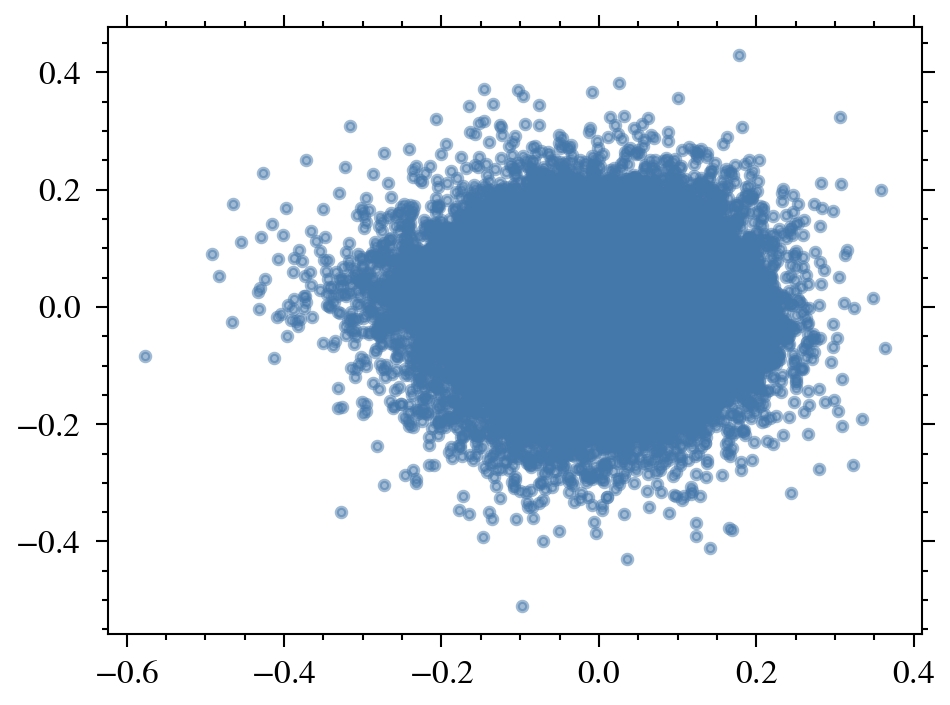

In [ ]:
pca = PCA(n_components=2)
pca_comps = pca.fit_transform(train_latents2)
plt.scatter(pca_comps[:,0], pca_comps[:,1], s=5,alpha=0.5)

In [ ]:
np.mean(train_latents2)

Array(7.992867e-06, dtype=float32)

In [ ]:
test=train_latents2.reshape(17000000,)

(array([1.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        1.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 1.000000e+00, 1.000000e+00,
        1.000000e+00, 1.000000e+00, 3.000000e+00, 1.000000e+00,
        1.000000e+00, 2.000000e+00, 4.000000e+00, 2.000000e+00,
        4.000000e+00, 4.000000e+00, 6.000000e+00, 8.000000e+00,
        3.000000e+00, 5.000000e+00, 6.000000e+00, 8.000000e+00,
        5.000000e+00, 1.300000e+01, 1.800000e+01, 1.900000e+01,
        2.500000e+01, 2.700000e+01, 4.300000e+01, 4.600000e+01,
        6.700000e+01, 6.700000e+01, 7.800000e+01, 7.900000e+01,
        1.290000e+02, 1.440000e+02, 1.800000e+02, 2.340000e+02,
        2.520000e+02, 2.930000e+02, 3.890000e+02, 4.280000e+02,
        5.690000e+02, 7.220000e+02, 8.970000e+02, 1.070000e+03,
        1.291000e+03, 1.608000e+03, 2.146000e+03, 2.596000e+03,
        3.083000e+03, 3.848000e+03, 4.880000e+03, 6.170000e+03,
        7.648000e+03, 9.551000e+03, 1.18

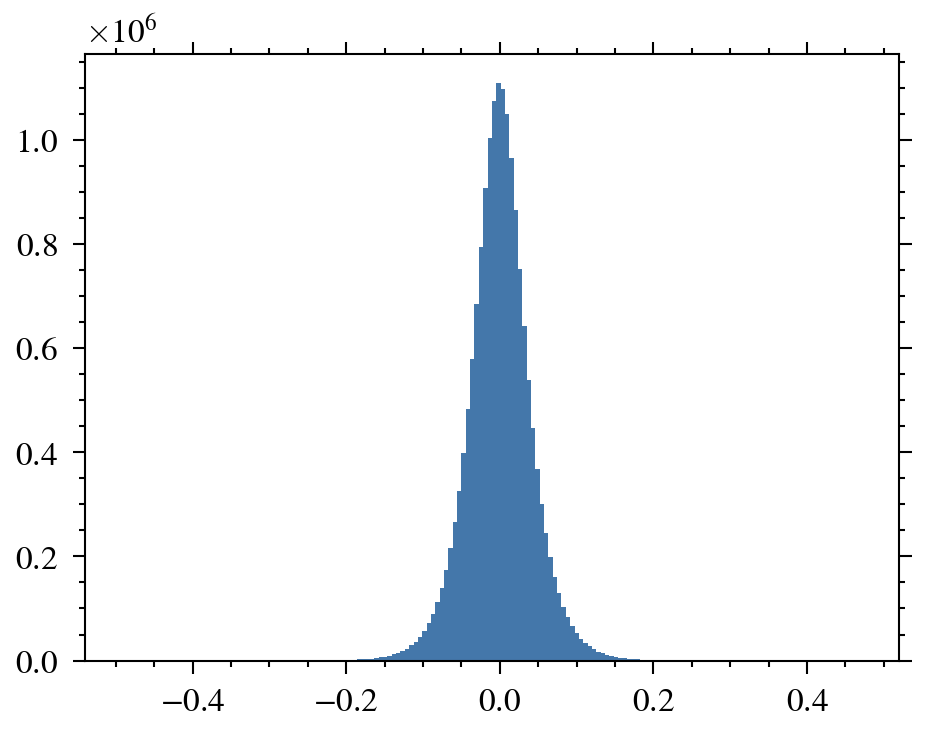

In [ ]:
plt.hist(test,bins=170)

In [53]:
np.savez('/Users/jonahgoldfine/Documents/Important Documents/packages/frito/_data/autoencoder/svd/PPD_retrain_model_7_4_svd.npz', u=u, s=s, v=v, mean=train_latents_mean)
